# <center>Homework 101

In [95]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time
from pathlib import Path
from time import strftime

In [10]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [5]:
len(np.unique(y_train))

10

tensorboard --logdir my_logs

In [94]:
def get_run_logdir(root_logdir="my_logs"):
    return Path(root_logdir) / strftime("run_%Y_%m_%d_%H_%M_%S")

In [12]:
inp = tf.keras.layers.Input(shape=X_train.shape[1:])

norm = tf.keras.layers.Normalization()
norm.adapt(X_train)
norm = norm(inp)

flatten = tf.keras.layers.Flatten()(inp)
hidden1 = tf.keras.layers.Dense(50, activation='relu', name='hd1')(flatten)
hidden2 = tf.keras.layers.Dense(40, activation='relu', name='hd2')(hidden1)
hidden3 = tf.keras.layers.Dense(30, activation='relu', name='hd3')(hidden2)
hidden4 = tf.keras.layers.Dense(20, activation='relu', name='hd4')(hidden3)
output = tf.keras.layers.Dense(10, activation='softmax', name='out')(hidden4)

model = tf.keras.Model(inputs=[inp], outputs=[output])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

run_logdir = get_run_logdir()

tensorboard_cb = tf.keras.callbacks.TensorBoard(run_logdir, profile_batch=(100, 200))

start = time.time()
history = model.fit(X_train, y_train, epochs=20, batch_size=100, 
           validation_data=(X_valid, y_valid)) # callbacks=[tensorboard_cb]
end = time.time()

total_fittime = end - start
total_fittime

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hd1 (Dense)                     │ (None, 50)             │        39,250 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hd2 (Dense)                     │ (None, 40)             │         2,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hd3 (Dense)                     │ (None, 30)             │         1,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hd4 (Dense)                     │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 10)             │           210 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,350 (169.34 KB)

 Trainable params: 43,350 (169.34 KB)

 Non-trainable params: 0 (0.00 B)

2026-01-06 17:13:16.667470: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:103] Profiler session initializing.
2026-01-06 17:13:16.667518: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:118] Profiler session started.
2026-01-06 17:13:16.667606: I external/local_tsl/tsl/profiler/lib/profiler_session.cc:136] Profiler session tear down.


Epoch 1/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.2960 - loss: 2.2455 - val_accuracy: 0.4472 - val_loss: 1.4306
Epoch 2/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5638 - loss: 1.1116 - val_accuracy: 0.5956 - val_loss: 0.9412
Epoch 3/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6700 - loss: 0.8668 - val_accuracy: 0.6490 - val_loss: 0.8353
Epoch 4/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7109 - loss: 0.7752 - val_accuracy: 0.7510 - val_loss: 0.7155
Epoch 5/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7604 - loss: 0.6783 - val_accuracy: 0.7704 - val_loss: 0.6573
Epoch 6/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7949 - loss: 0.5959 - val_accuracy: 0.8216 - val_loss: 0.5499
Epoch 7/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8284 - loss: 0.5080 - val_accuracy: 0.8392 - val_loss: 0.4883
Epoch 8/20
550/550 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8419 - loss: 0.4578 - val_accuracy: 0.

54.544962882995605

In [13]:
history.history

{'accuracy': [0.2959636449813843,
  0.5638363361358643,
  0.670018196105957,
  0.7109454274177551,
  0.760381817817688,
  0.7948727011680603,
  0.8284363746643066,
  0.8419272899627686,
  0.8495272994041443,
  0.8547999858856201,
  0.8597090840339661,
  0.8629090785980225,
  0.8678727149963379,
  0.8691636323928833,
  0.8736545443534851,
  0.8747818470001221,
  0.8772000074386597,
  0.8775454759597778,
  0.8820182085037231,
  0.8838545680046082],
 'loss': [2.245495557785034,
  1.1116214990615845,
  0.8668183088302612,
  0.7751674652099609,
  0.6783197522163391,
  0.595900297164917,
  0.5079661011695862,
  0.45777854323387146,
  0.42938995361328125,
  0.4085959494113922,
  0.3900199830532074,
  0.38026952743530273,
  0.3684873878955841,
  0.36088380217552185,
  0.3486873209476471,
  0.3437325358390808,
  0.335431843996048,
  0.3314236104488373,
  0.3236183226108551,
  0.31824401021003723],
 'val_accuracy': [0.4472000002861023,
  0.5956000089645386,
  0.6489999890327454,
  0.750999987125

In [ ]:
test_logdir = get_run_logdir()
writer = tf.summary.create_file_writer(str(test_logdir))
with writer.as_default():
    for step in range(1, 1000 + 1):
        tf.summary.scalar("my_scalar", np.sin(step / 10), step=step)
        
        data = (np.random.randn(100) + 2) * step / 100 # gets larger
        tf.summary.histogram("my_hist", data, buckets=50, step=step)

        images = np.random.rand(2, 32, 32, 3) * step / 1000
        tf.summary.image("my_images", images, step=step)

        # gets brighter
        texts = ["The step is " + str(step), "Its square is " + str(step ** 2)]
        tf.summary.text("my_text", texts, step=step)

        sine_wave = tf.math.sin(tf.range(12000) / 48000 * 2 * np.pi * step)
        audio = tf.reshape(tf.cast(sine_wave, tf.float32), [1, -1, 1])
        tf.summary.audio("my_audio", audio, sample_rate=48000, step=step)

## Task 4

In [2]:
from importlib import reload
import keras_tuner as kt
import finetuning 

2026-01-06 19:42:22.896875: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-06 19:42:23.660591: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-06 19:42:27.009402: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [13]:
# X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.
X_train = X_train[:10_000]
y_train = y_train[:10_000]

In [30]:
reload(finetuning)
from finetuning import RandomSearch

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=0, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=100)
    # print(n_neurons, type(n_neurons))
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log")
    
    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation="relu"))
    
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
    metrics=["accuracy"])
    return model


random_search_tuner = RandomSearch(build_model, objective="val_accuracy", max_trials=5, seed=42)
random_search_tuner.search(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.2183 - loss: 2.1018 - val_accuracy: 0.3026 - val_loss: 1.8572
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5023 - loss: 1.5113 - val_accuracy: 0.6430 - val_loss: 1.2252
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6621 - loss: 1.0720 - val_accuracy: 0.6834 - val_loss: 0.9581
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7010 - loss: 0.8916 - val_accuracy: 0.7232 - val_loss: 0.8284
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7307 - loss: 0.7937 - val_accuracy: 0.7448 - val_loss: 0.7513
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7548 - loss: 0.7281 - val_accuracy: 0.7666 - val_loss: 0.6935
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7733 - loss: 0.6797 - val_accuracy: 0.7810 - val_loss: 0.6520
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7859 - loss: 0.6429 - val_accuracy: 0

In [31]:
best_model = random_search_tuner.get_best_models()[0]
best_model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8481 - loss: 0.4653


[0.4652964472770691, 0.8481000065803528]

In [35]:
history = best_model.fit(X_train, y_train, epochs=5, validation_data=(X_valid, y_valid))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9173 - loss: 0.2240 - val_accuracy: 0.8640 - val_loss: 0.4596
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9202 - loss: 0.2156 - val_accuracy: 0.8598 - val_loss: 0.4618
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9278 - loss: 0.1980 - val_accuracy: 0.8546 - val_loss: 0.5589
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9241 - loss: 0.2170 - val_accuracy: 0.8588 - val_loss: 0.5132
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9284 - loss: 0.1938 - val_accuracy: 0.8636 - val_loss: 0.4801


In [36]:
history.history

{'accuracy': [0.9172999858856201,
  0.920199990272522,
  0.9277999997138977,
  0.9240999817848206,
  0.9283999800682068],
 'loss': [0.22398048639297485,
  0.2155773639678955,
  0.1979830414056778,
  0.21700778603553772,
  0.19382810592651367],
 'val_accuracy': [0.8640000224113464,
  0.8597999811172485,
  0.8546000123023987,
  0.8587999939918518,
  0.8636000156402588],
 'val_loss': [0.45958808064460754,
  0.4617907702922821,
  0.5589320659637451,
  0.5131826996803284,
  0.48008814454078674]}

In [41]:
reload(finetuning)
from finetuning import Hyperband

tuner = Hyperband(build_model, objective="val_accuracy", max_epochs=10, 
                  factor=3, seed=42, project_name='test_hyperband')
tuner.search(X_train, y_train, validation_data=(X_valid, y_valid))

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.3506 - loss: 1.9314 - val_accuracy: 0.4680 - val_loss: 1.6186
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5693 - loss: 1.3725 - val_accuracy: 0.6318 - val_loss: 1.1677
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6506 - loss: 1.0527 - val_accuracy: 0.6808 - val_loss: 0.9458
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7084 - loss: 0.8861 - val_accuracy: 0.7350 - val_loss: 0.8264
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7358 - loss: 0.7921 - val_accuracy: 0.7510 - val_loss: 0.7531
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.2590 - loss: 2.0552 - val_accuracy: 0.4004 - val_loss: 1.5756
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5986 - loss: 1.1052 - val_accuracy: 0.7000 - val_loss: 0.8444
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6814 - loss: 0.8339 - val_accuracy: 0.6986 - v

In [42]:
tuner.best_model_.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8571 - loss: 0.4648


[0.4647882878780365, 0.8571000099182129]

## Task 6

In [55]:
(X_train_full, y_train_full), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train, y_train, X_val, y_val = X_train_full[:-5000], y_train_full[:-5000], X_train_full[-5000:], y_train_full[-5000:]

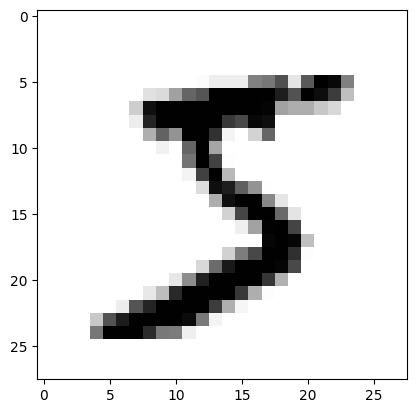

In [50]:
plt.imshow(X_train[0], cmap='binary')

In [52]:
inp = tf.keras.layers.Input(X_train.shape[1:])

norm = tf.keras.layers.Normalization()
norm.adapt(X_train)
norm = norm(inp)

flatten = tf.keras.layers.Flatten()(norm)
hd1 = tf.keras.layers.Dense(300, activation='relu')(flatten)
hd2 = tf.keras.layers.Dense(200, activation='relu')(hd1)
hd3 = tf.keras.layers.Dense(100, activation='relu')(hd2)

output = tf.keras.layers.Dense(10, activation='softmax')(hd3)

model = tf.keras.Model(inputs=[inp], outputs=[output])

optimizer = tf.keras.optimizers.Adam()
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

model.fit(X_train, y_train, validation_data=(X_val, y_val))

Model: "functional_118"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_45 (InputLayer)     │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization_1 (Normalization) │ (None, 28, 28)         │            57 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_52 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_205 (Dense)               │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_206 (Dense)               │ (None, 200)            │        60,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_207 (Dense)               │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_208 (Dense)               │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 316,867 (1.21 MB)

 Trainable params: 316,810 (1.21 MB)

 Non-trainable params: 57 (232.00 B)

2026-01-06 23:38:37.013790: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 43120000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.9365 - loss: 0.2152 - val_accuracy: 0.9688 - val_loss: 0.1146


In [53]:
model.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
   9/1719 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - accuracy: 0.9728 - loss: 0.1156

2026-01-06 23:39:48.855326: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 43120000 exceeds 10% of free system memory.


1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9695 - loss: 0.0998 - val_accuracy: 0.9728 - val_loss: 0.0980
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9780 - loss: 0.0716 - val_accuracy: 0.9780 - val_loss: 0.0825
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9825 - loss: 0.0567 - val_accuracy: 0.9766 - val_loss: 0.0880
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9859 - loss: 0.0458 - val_accuracy: 0.9794 - val_loss: 0.0839
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9879 - loss: 0.0406 - val_accuracy: 0.9792 - val_loss: 0.0991
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9906 - loss: 0.0326 - val_accuracy: 0.9748 - val_loss: 0.1128
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.9905 - loss: 0.0316 - val_accuracy: 0.9756 - val_loss: 0.1243
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9925 - loss: 0.02

In [56]:
loss, test_acc = model.evaluate(X_test, y_test)
test_acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9759 - loss: 0.1387


0.9758999943733215

In [62]:
factor = (10 / (10**-5))**(1/500)
start_lr = 10**-5

for i in range(10):
    print(start_lr)
    start_lr *= factor


1e-05
1.0280162981264736e-05
1.0568175092136586e-05
1.0864256236170656e-05
1.1168632477805613e-05
1.148153621496883e-05
1.18032063565173e-05
1.2133888504649777e-05
1.2473835142429435e-05
1.282330582656022e-05


In [73]:
class ExponentialLearningRate(tf.keras.callbacks.Callback):
    def __init__(self, factor):
        self.factor = factor
        self.rates = []
        self.losses = []

    def on_batch_end(self, batch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy() * self.factor
        self.model.optimizer.learning_rate = lr
        self.rates.append(lr)
        self.losses.append(logs["loss"])


factor = (10 / (10**-5))**(1/500)
start_lr = 10**-5

model_lr = tf.keras.models.clone_model(model)

optimizer = tf.keras.optimizers.SGD(learning_rate=start_lr)
model_lr.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy')

exp_lr = ExponentialLearningRate(1.005)

history = model_lr.fit(X_train, y_train, epochs=1, callbacks=[exp_lr])

1719/1719 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.6397 - loss: nan


Text(0, 0.5, 'Loss')

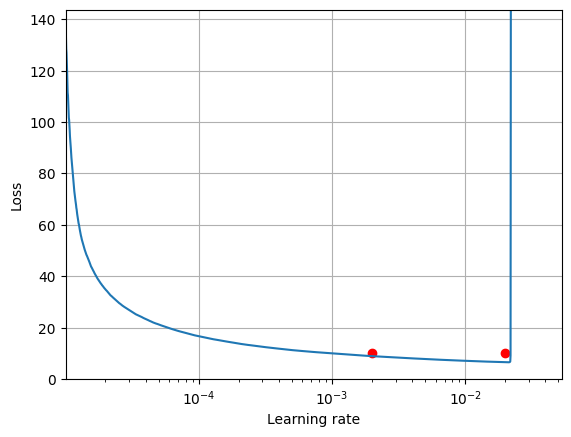

In [89]:
plt.plot(exp_lr.rates, exp_lr.losses)
plt.gca().set_xscale('log')
plt.axis([min(exp_lr.rates), max(exp_lr.rates), 0, exp_lr.losses[0]])
plt.scatter(10**-1.7, 10, c='r')
plt.scatter((10**-1.7) / 10, 10, c='r')
plt.grid()
plt.xlabel("Learning rate")
plt.ylabel("Loss")

In [90]:
optimal_lr = (10**-1.7) / 10

In [91]:
model1 = tf.keras.models.clone_model(model)
optimizer = tf.keras.optimizers.SGD(optimal_lr)
model1.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy')

history1 = model1.fit(X_train, y_train, epochs=10, validation_data=(X_val, y_val))

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8539 - loss: 0.8151 - val_accuracy: 0.9280 - val_loss: 0.2442
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9348 - loss: 0.2135 - val_accuracy: 0.9464 - val_loss: 0.1756
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9523 - loss: 0.1522 - val_accuracy: 0.9568 - val_loss: 0.1529
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9631 - loss: 0.1181 - val_accuracy: 0.9562 - val_loss: 0.1489
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9710 - loss: 0.0939 - val_accuracy: 0.9638 - val_loss: 0.1382
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9763 - loss: 0.0754 - val_accuracy: 0.9636 - val_loss: 0.1446
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9811 - loss: 0.0624 - val_accuracy: 0.9612 - val_loss: 0.1558
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9844 - loss: 0

In [92]:
import keras_tuner as kt

def build_model(hp):
    n_hidden = hp.Int("n_hidden", min_value=1, max_value=8, default=2)
    n_neurons = hp.Int("n_neurons", min_value=16, max_value=256, default=50)
    learning_rate = hp.Float("learning_rate", min_value=1e-4, max_value=1e-2, sampling="log", default=optimal_lr)

    optimizer = hp.Choice("optimizer", values=["sgd", "adam"])
    if optimizer == "sgd":
        optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    activation = hp.Choice("activation", values=["relu", "tanh"])

    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Flatten())
    for _ in range(n_hidden):
        model.add(tf.keras.layers.Dense(n_neurons, activation=activation))
    
    model.add(tf.keras.layers.Dense(10, activation="softmax"))
    model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])
    return model

In [ ]:
tuner = kt.Hyperband(build_model, objective="val_accuracy", max_epochs=20,
    factor=3, directory="my_dir", project_name="mnist")

log_dir = get_run_logdir('my_logs2')
tensorboard_cb = tf.keras.callbacks.TensorBoard(log_dir=log_dir)

callbacks = [tf.keras.callbacks.EarlyStopping(patience=3), tensorboard_cb]
tuner.search(X_train, y_train, validation_data=(X_val, y_val), callbacks=callbacks)

Trial 30 Complete [00h 03m 18s]
val_accuracy: 0.9215999841690063

Best val_accuracy So Far: 0.9760000109672546
Total elapsed time: 00h 48m 04s


In [97]:
best_model1 = tuner.get_best_models()[0]
best_model1.evaluate(X_test, y_test)

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9699 - loss: 0.1296


[0.12959785759449005, 0.9699000120162964]

In [102]:
tuner.get_best_hyperparameters(1)[0].values

{'n_hidden': 7,
 'n_neurons': 131,
 'learning_rate': 0.0002249755313619729,
 'optimizer': 'adam',
 'activation': 'relu',
 'tuner/epochs': 20,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}

In [106]:
%load_ext tensorboard
%tensorboard --logdir my_logs2 

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 82724), started 7:58:40 ago. (Use '!kill 82724' to kill it.)